In [1]:
import piplite
# await piplite.install('seaborn')

In [2]:
import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# from sklearn.linear_model import LinearRegression, Ridge
# from sklearn.metrics import mean_squared_error, r2_score
# from sklearn.model_selection import cross_val_score, train_test_split

<ipython-input-2-da606197d11b>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
from pyodide.http import pyfetch

# async def download(url, filename):
#     response = await pyfetch(url)
#     if response.status == 200:
#         with open(filename, "wb") as f:
#             f.write(await response.bytes())

In [4]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'

In [5]:
await download(filepath, "insurance.csv")
# file_name="insurance.csv"

In [6]:
df = pd.read_csv(file_name)

In [7]:
#filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
#df = pd.read_csv(filepath, header=None)

In [8]:
df = pd.read_csv("insurance.csv",header = None)
# df.head()

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [9]:
headers = ["age","gender","bmi","no_of_childern","smoker","region","charges"]
# df.columns = headers

# df.head()

,age,gender,bmi,no_of_childern,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [10]:
df.replace('?', np.nan, inplace = True)
# df.head()

,age,gender,bmi,no_of_childern,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_childern  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 130.0+ KB
None


In [12]:
is_smoker = df['smoker'].value_counts().idxmax()
# df["smoker"] = df["smoker"].fillna(is_smoker)

# df["age"] = pd.to_numeric(df["age"],errors = "coerce")

# age_mean = df["age"].mean()
# df["age"] =  df["age"].replace(np.nan,age_mean)


# df[["age","smoker"]] = df[["age","smoker"]].astype("int")

In [13]:
df[["charges"]] = np.round(df[["charges"]],2)

(0.0, 66902.85800000001)

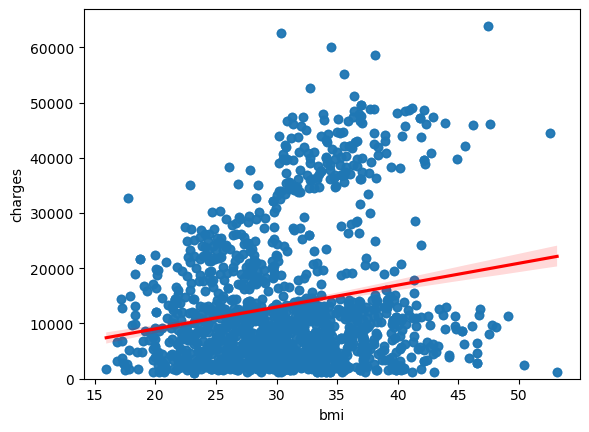

In [14]:
sns.regplot(x="bmi",y = "charges",data = df , line_kws = {"color": "red"})
# plt.ylim(0,)

<AxesSubplot:xlabel='smoker', ylabel='charges'>

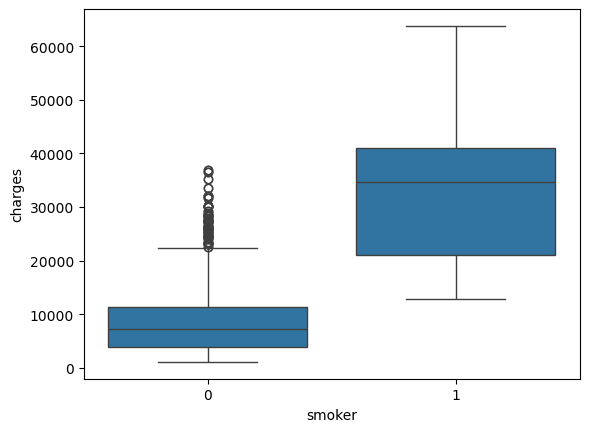

In [15]:
sns.boxplot(x="smoker", y="charges",data = df)

In [16]:
print(df.corr())

                     age    gender       bmi  no_of_childern    smoker  \
age             1.000000 -0.026046  0.113048        0.037574 -0.023286   
gender         -0.026046  1.000000  0.042924        0.016020  0.082326   
bmi             0.113048  0.042924  1.000000       -0.001492  0.011489   
no_of_childern  0.037574  0.016020 -0.001492        1.000000  0.006362   
smoker         -0.023286  0.082326  0.011489        0.006362  1.000000   
region         -0.007167  0.022213  0.271119       -0.025717  0.054077   
charges         0.298624  0.062837  0.199846        0.066442  0.788783   

                  region   charges  
age            -0.007167  0.298624  
gender          0.022213  0.062837  
bmi             0.271119  0.199846  
no_of_childern -0.025717  0.066442  
smoker          0.054077  0.788783  
region          1.000000  0.054058  
charges         0.054058  1.000000  


In [20]:
X = df[['smoker']]
# Y = df['charges']
# lm = LinearRegression()
# lm.fit(X,Y)
# print(lm.score(X, Y))


0.6221791733924185


In [24]:
Z = df[["age", "gender", "bmi", "no_of_childern", "smoker", "region"]]
# lm.fit(Z,Y)
# print(lm.score(Z, Y))


0.7504083820289634


In [26]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
# pipe = Pipeline(Input)
# Z = Z.astype(float)
# pipe.fit(Z,Y)
# ypipe = pipe.predict(Z)
# print(r2_score(Y,ypipe))

0.8451876102882967


In [27]:
x_train,x_test,y_train,y_test = train_test_split(Z,Y,test_size=0.2,random_state = 1)

In [28]:
RidgeModel = Ridge(alpha=0.1)
# RidgeModel.fit(x_train,y_train)
# y_hat = RidgeModel.predict(x_test)
# print(r2_score(y_test,y_hat))

0.6760807731582404


In [29]:
pr = PolynomialFeatures(degree=2)
# x_train_pr = pr.fit_transform(x_train)
# x_test_pr = pr.transform(x_test)
# RidgeModel.fit(x_train_pr, y_train)
# y_hat = RidgeModel.predict(x_test_pr)
# print(r2_score(y_test,y_hat))

0.7835631107608061
